<table align="left" width="100%"> <tr>
 <td style="background-color:#ffffff;"><a href=https://qworld.net/index.php/qworld/" target="_blank"><img src="../images/qworld.jpg" width="35%" align="left"></a></td>
 <td align="right" style="background-color:#ffffff;vertical-align:bottom;horizontal-align:right">
 prepared by Özlem Salehi (<a href="https://qworld.net/index.php/qturkey/" target="_blank">QTurkey</a>)
 </td>
</tr></table>

<table width="100%"><tr><td style="color:#555555;background-color:#f5f5f5;font-size:12px;font-style:italic;">This notebook is a **Qiskit port** of QWorld Silver's original notebook (Cirq), prepared by Ahmed Elghadban for QSaudi Arabia's QSilver39 course. All conceptual / "on paper" content is unchanged from the original; only the circuit-implementation cells (Tasks 1, 5-7) are rewritten for Qiskit. Original content © QWorld, CC BY 4.0.</td></tr></table>

<table width="100%"><tr><td style="color:#bbbbbb;background-color:#ffffff;font-size:11px;font-style:italic;text-align:right;">This cell contains some macros. If there is a problem with displaying mathematical formulas, please run this cell to load these macros. </td></tr></table>
$\newcommand{\Mod}[1]{\ (\mathrm{mod}\ #1)}$
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\ \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0} } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1} } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $

<h1> <font color="blue"> Solutions for </font> Order Finding Algorithm</h1>

<a id="task1"></a>
<h3>Task 1</h3>

Let $x=5$ and $N=21$. Plot $x^ i \Mod{N}$ for $i$ values between $1$ and $50$ and find the order of $x$.

<h3>Solution </h3>

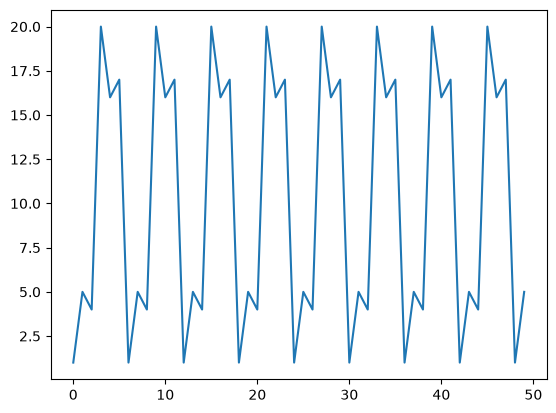

In [1]:
import matplotlib.pyplot as plt

#Create an empty list
l = []
x = 5
N = 21

#Append x^i mod N values
for i in range(50):
    l.append((x**i) % N)

plt.plot(l)
plt.show()

Let's check each integer and stop when we find an integer $r$ satisfying $x^r = 1\Mod{N}$

$ 5^1 = 5 ~\mod 21 $

$ 5^2 = 4 ~\mod 21  $

$ 5^3 = 20 \mod 21 $

$ 5^4 = 16 \mod 21 $

$ 5^5 = 17 \mod 21 $

$ 5^6 = 1 ~\mod 21  $

Hence the order $r$ is equal to 6.

<a id="task2"></a>
<h3>Task 2 (on paper)</h3>

Let $\ket{\psi_0}=\ket{1 \Mod{N}}+\ket{x\Mod{N}}+\ket{x^2\Mod{N}}+ \cdots + \ket{x^{r-1}\Mod{N}}$. 

What is $U_x \ket{\psi_0}$? What can you conclude about $\ket{\psi_0}$?

Repeat the same task for $\ket{\psi_1}=\ket{1 \Mod{N}}+ \omega^{-1}\ket{x\Mod{N}}+\omega^{-2}\ket{x^2\Mod{N}}+ \cdots + \omega^{-(r-1)} \ket{x^{r-1}\Mod{N}}$.

<h3>Solution </h3>

$U_x$ maps $\ket{x^i \Mod N}$ to $\ket{x^{i+1}\Mod N}$. Applying $U_x$ to $\ket{\psi_0}$ therefore just permutes its terms cyclically:

$$
U_x\ket{\psi_0} = \ket{x \Mod N} + \ket{x^2\Mod N} + \cdots + \ket{x^{r-1}\Mod N} + \ket{x^r\Mod N} = \ket{\psi_0}
$$

(using $x^r = 1 \Mod N$ for the last term). So $\ket{\psi_0}$ is an eigenvector of $U_x$ with eigenvalue $1$.

For $\ket{\psi_1}$, applying $U_x$ shifts every exponent up by one and multiplies through by $\omega$ (since every term's $\omega^{-i}$ becomes $\omega^{-(i-1)} = \omega \cdot \omega^{-i}$ relative to the shifted labeling), giving

$$
U_x\ket{\psi_1} = \omega\,\ket{\psi_1}.
$$

So $\ket{\psi_1}$ is also an eigenvector, this time with eigenvalue $\omega = e^{2\pi i/r}$ — exactly the $s=1$ case of the general $\ket{u_s}$ family used below.

<a id="task3"></a>
<h3>Task 3 (on paper)</h3>

Show that $\frac{1}{\sqrt{r}}\sum_{s=0}^{r-1}\ket{u_s}= \ket{1}$.

<h3>Solution </h3>

Substituting the definition of $\ket{u_s}$ and swapping the order of summation,

$$
\frac{1}{\sqrt r}\sum_{s=0}^{r-1}\ket{u_s} = \frac{1}{r}\sum_{s=0}^{r-1}\sum_{k=0}^{r-1} e^{-2\pi i sk/r}\ket{x^k \Mod N} = \frac{1}{r}\sum_{k=0}^{r-1}\left(\sum_{s=0}^{r-1} e^{-2\pi i sk/r}\right)\ket{x^k\Mod N}.
$$

The inner sum $\sum_{s=0}^{r-1} e^{-2\pi i sk/r}$ is a geometric series that equals $r$ when $k=0 \Mod r$ and $0$ otherwise (the standard "sum of roots of unity" identity). Since $0 \le k \le r-1$, only the $k=0$ term survives, and $x^0 \Mod N = 1$. So the whole expression collapses to $\frac{1}{r}\cdot r \cdot \ket{1} = \ket{1}$.

<h2>Continued Fractions</h2>

In [2]:
import sys
sys.path.append('../include')
from helpers import contFrac, convergents

In [3]:
cf = contFrac(25/11)
print(cf)

[2, 3, 1, 2]


In [4]:
cv = convergents(cf)
print(cv)

[Fraction(2, 1), Fraction(7, 3), Fraction(9, 4), Fraction(25, 11)]


In [5]:
cv = convergents([1,4,2,1])
print(cv)

[Fraction(1, 1), Fraction(5, 4), Fraction(11, 9), Fraction(16, 13)]


<a id="task4"></a>
<h3>Task 4</h3>

Find the continued fractions expression for $\frac{31}{13}$ and the convergents first using pen and paper and then using the functions defined above.

<h3>Solution </h3>

By hand: $\frac{31}{13} = 2 + \frac{5}{13} = 2+\cfrac{1}{13/5} = 2+\cfrac{1}{2+\frac{3}{5}} = 2+\cfrac{1}{2+\cfrac{1}{5/3}} = 2+\cfrac{1}{2+\cfrac{1}{1+\frac{2}{3}}} = 2+\cfrac{1}{2+\cfrac{1}{1+\cfrac{1}{3/2}}} = 2+\cfrac{1}{2+\cfrac{1}{1+\cfrac{1}{1+\frac12}}}$, i.e. continued fraction $[2,2,1,1,2]$, with convergents $2,\ \frac52,\ \frac73,\ \frac{12}{5},\ \frac{31}{13}$.

In [6]:
cf = contFrac(31/13)
print(cf)
cv = convergents(cf)
print(cv)

[2, 2, 1, 1, 2]
[Fraction(2, 1), Fraction(5, 2), Fraction(7, 3), Fraction(12, 5), Fraction(31, 13)]


### Choice of t (optional)

<hr>

<a id="task5"></a>
<h3>Task 5</h3>

You are given a function named $U_x$ which implements $ U_x \ket{y} \rightarrow \ket{xy {\Mod{N}}}$ and returns its controlled version. Run the following cell to load the function.

<h3>Solution </h3>

In [7]:
from operator_cu import Ux
from qpe import qpe

In [8]:
import math
L = math.ceil(math.log2(20))
print(L)

5


In [9]:
e = 0.1
num_t = 2*L + 1 + math.ceil(math.log2(2 + 1/(2*e)))
print(num_t)

14


In [10]:
def decode_counts(counts, t):
    """AerSimulator counts (bitstrings, qubit 0 rightmost) -> {x: count},
    where x reads the control register with control[0] as the
    most-significant bit (same convention as iqft.py/qpe.py)."""
    decoded = {}
    for bits, cnt in counts.items():
        x = int(bits[-t:][::-1], 2)
        decoded[x] = decoded.get(x, 0) + cnt
    return decoded

In [11]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

#Assign the size of the registers
t = num_t
n = L

circuit = QuantumCircuit(t + n, t)

#Create control and target qubits (just use qubit indices)
control = list(range(t))
target = list(range(t, t + n))

#Set target register to |1> (target[-1] is the least-significant qubit, see qpe.py)
circuit.x(target[-1])

#Create operator CU
x = 3
N = 20
CU = Ux(x, N)

#Call phase estimation circuit
qpe(t, control, target, circuit, CU)

#Measure the control register
circuit.measure(control, range(t))

#Sample the circuit
sim = AerSimulator()
print('Sample the circuit:')
result = sim.run(transpile(circuit, sim), shots=1000).result()
counts = result.get_counts()
print(counts)

Sample the circuit:
{'00000000000001': 252, '00000000000011': 248, '00000000000010': 243, '00000000000000': 257}


{8192: 252, 12288: 248, 4096: 243, 0: 257}


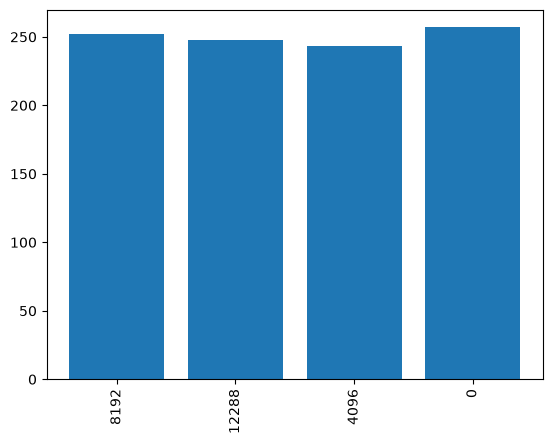

In [12]:
decoded = decode_counts(counts, t)
print(decoded)
plt.bar([str(k) for k in decoded.keys()], decoded.values())
plt.xticks(rotation=90)
plt.show()

Peaks occur at (in binary, reading the control register with the first control qubit as the most-significant bit — see `qpe.py`) 0, 4096, 8192 and 12288 out of $2^{14}=16384$, i.e. at $\frac{s}{4}$ for $s=0,1,2,3$: exactly what we'd expect for an operator whose order is $r=4$.

<a id="task6"></a>
<h3>Task 6</h3>

For each one of the possible outcomes in Task 5, try to find out the value of $r$ using continued fractions algorithm. You can use the functions defined above.

<h3>Solution </h3>

In [13]:
for peak in [4096, 8192, 12288]:
    cf = contFrac(peak / 2**14)
    cv = convergents(cf)
    print(peak, '/ 2^14 ->', cv)

4096 / 2^14 -> [Fraction(0, 1), Fraction(1, 4)]
8192 / 2^14 -> [Fraction(0, 1), Fraction(1, 2)]
12288 / 2^14 -> [Fraction(0, 1), Fraction(1, 1), Fraction(3, 4)]


Each convergent's denominator is a candidate for $r$ (or a factor of $r$) — here they all point straight at $r=4$, and indeed $3^4 = 81 = 4\times20+1 \equiv 1 \Mod{20}$.

<a id="task7"></a>
<h3>Task 7</h3>

Repeat Task 5 and Task 6 with $x=5$ and $N=42$.

<h3>Solution </h3>

In [14]:
L = math.ceil(math.log2(42))
print(L)

6


In [15]:
num_t = 2*L + 1 + math.ceil(math.log2(2 + 1/(2*e)))
print(num_t)

16


In [16]:
t = num_t
n = L

circuit = QuantumCircuit(t + n, t)
control = list(range(t))
target = list(range(t, t + n))

circuit.x(target[-1])

x = 5
N = 42
CU = Ux(x, N)

qpe(t, control, target, circuit, CU)

circuit.measure(control, range(t))

sim = AerSimulator()
print('Sample the circuit:')
result = sim.run(transpile(circuit, sim), shots=1000).result()
counts = result.get_counts()
print(counts)

Sample the circuit:
{'0001101010101011': 3, '0111010101010100': 2, '1101010101010101': 128, '1010101010101011': 126, '0011010101010101': 4, '0000000000000000': 168, '1101101010101010': 1, '1110101010101011': 6, '0011010101010100': 4, '0000000000000001': 154, '1111100101010101': 1, '1011011010101011': 1, '0110101010101010': 32, '0101010101010100': 24, '1010101010101010': 111, '0101010101010101': 24, '1011111010101011': 1, '1101010101010100': 113, '0010101010101010': 8, '1001010101010100': 9, '1100010101010101': 1, '0010101010101011': 6, '1000101010101010': 2, '0001101010101010': 4, '0100101010101010': 2, '0100110101010100': 1, '0110101010101011': 14, '0001010101010101': 3, '0100101010101011': 1, '1001010101010101': 3, '1000101010101011': 2, '1001101010101010': 1, '1011010101010100': 4, '1111101010101010': 1, '1011010101010101': 4, '1100101010101010': 3, '0000011010101010': 1, '0011101010101010': 2, '1000011001010100': 1, '0000101010101010': 3, '1011101010101010': 1, '1111010101010101': 

{54616: 3, 10926: 2, 43691: 128, 54613: 126, 43692: 4, 0: 168, 21851: 1, 54615: 6, 10924: 4, 32768: 154, 43679: 1, 54637: 1, 21846: 32, 10922: 24, 21845: 111, 43690: 24, 54653: 1, 10923: 113, 21844: 8, 10921: 9, 43683: 1, 54612: 6, 21841: 2, 21848: 4, 21842: 2, 10930: 1, 54614: 14, 43688: 3, 54610: 1, 43689: 3, 54609: 2, 21849: 1, 10925: 4, 21855: 1, 43693: 4, 21843: 3, 21856: 1, 21852: 2, 10849: 1, 21840: 3, 21853: 1, 43695: 2, 54651: 1, 54604: 1, 54624: 1, 54611: 3, 10919: 1, 10952: 1, 43702: 1, 54647: 1, 21812: 1, 10944: 1, 43694: 2, 44031: 1, 10920: 2, 21847: 1}


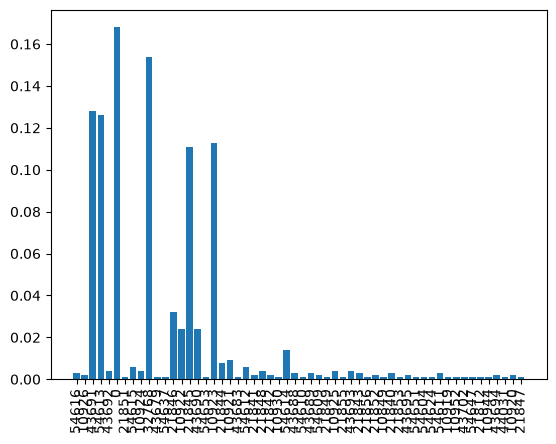

In [18]:
decoded = decode_counts(counts, t)
print(decoded)
total = sum(decoded.values())
plt.bar([str(k) for k in decoded.keys()], [v / total for v in decoded.values()])
plt.xticks(rotation=90)
plt.show()

In [19]:
for peak in [10923, 21845, 32768, 43691, 54613]:
    cf = contFrac(peak / 2**16)
    cv = convergents(cf)
    print(peak, '/ 2^16 ->', cv)

10923 / 2^16 -> [Fraction(0, 1), Fraction(1, 5), Fraction(1, 6), Fraction(1, 6), Fraction(1, 6)]
21845 / 2^16 -> [Fraction(0, 1), Fraction(1, 3)]
32768 / 2^16 -> [Fraction(0, 1), Fraction(1, 2)]
43691 / 2^16 -> [Fraction(0, 1), Fraction(1, 1), Fraction(2, 3)]
54613 / 2^16 -> [Fraction(0, 1), Fraction(1, 1), Fraction(4, 5), Fraction(5, 6), Fraction(5, 6), Fraction(5, 6)]


The peaks sit at multiples of $\frac{1}{6}$ of $2^{16}=65536$ (0, 10923, 21845, 32768, 43691, 54613), and continued fractions on each recovers $r=6$: indeed $5^6 = 15625 = 372\times42+1 \equiv 1 \Mod{42}$.

<h2>Remarks about the algorithm</h2>

- Algorithm might produce a bad estimate to $\frac{s}{r}$ which occurs with probability at most $ \epsilon $. This problem can be improved, but in the cost of increasing the size of the circuit.

- As we have seen in Task 6 and Task 7, $s$ and $r$ may have a common factor, and we may get $r'$ (which is a factor of $r$) instead of $r$. Nevertheless, the number of primes which are less than $r$ is at least $\frac{r}{2}\log r$. With a constant number of repetitions of the algorithm, one can obtain $s$ and $r$ which are relatively prime with high probability.

- Overall, we have an algorithm which uses $O(L^3)$ gates, $ O(L) $ qubits and constant repetitions.

 - Hadamard operation at the beginning requires $ O(L) $ gates
 - $ O(L^2) $ gates are required by $QFT^\dagger $
 - $ O(L^3) $ gates are needed for modular exponentiation
 - Continued fraction algorithm requires $ O(L^3) $ classical processing

The best classical algorithm for order finding is of exponential time while we have a polynomial size quantum circuit for order finding. 